<a href="https://colab.research.google.com/github/Bubukisapisa/ML_education/blob/main/HW_%D0%9C%D0%B5%D1%82%D0%BE%D0%B4%D0%B8_%D0%BF%D0%BE%D0%BD%D0%B8%D0%B6%D0%B5%D0%BD%D0%BD%D1%8F_%D1%80%D0%BE%D0%B7%D0%BC%D1%96%D1%80%D0%BD%D0%BE%D1%81%D1%82%D1%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Домашнє завдання: Пониження розмірностей для Аналізу Портретів Клієнтів

#### Контекст
В цьому ДЗ ми попрацюємо з методами пониження розмірності на наборі даних для задачі аналізу портретів клієнтів (Customer Personality Analysis). **В попередньому ДЗ ми працювали з цими даними використовуючи кластеризацію, зараз використаємо кластеризацію і візуалізауємо результати з різними методами.**

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


Для початку, запустіть код нижче. Всі ці кроки ми робили в попередньому ДЗ і для того, щоб результати кластеризації у нас були схожими, потрібно аби передобробка була однаковою.

In [3]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn import metrics
import plotly.express as px
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

Mounted at /content/drive


In [4]:

# 1. Завантаження даних
df = pd.read_csv('drive/MyDrive/ML for people/marketing_campaign.csv', sep='\t')

# 2. Обробка пропущених значень
df['Income_not_filled'] = df.Income.isna()
df.Income = df.Income.fillna(-1)

# 3. Обробка дати реєстрації
df.Dt_Customer = pd.to_datetime(df.Dt_Customer, format='%d-%m-%Y')
today = df.Dt_Customer.max()
df['days_lifetime'] = (today - df.Dt_Customer).dt.days
df['years_customer'] = df.Year_Birth.apply(lambda x: today.year - x)

# 4. Категоризація рівня освіти
df_education = pd.get_dummies(df.Education, prefix='education').astype(int)
df = pd.concat([df, df_education], axis=1)

# 5. Очищення сімейного стану
marital_status_map = {'Alone': 'Single', 'Absurd': 'Else', 'YOLO': 'Else'}
df['Marital_Status_clean'] = df.Marital_Status.map(marital_status_map)
df_ms = pd.get_dummies(df.Marital_Status_clean, prefix='marital').astype(int)
df = pd.concat([df, df_ms], axis=1)

# 6. Форматування доходу і видалення викиду
df.Income = df.Income.astype(int)
df = df[df.Income != 666666]

# 7. Створення фінального набору даних
X = df.drop(['ID', 'Dt_Customer', 'Education', 'Marital_Status', 'Marital_Status_clean'], axis=1)
X.reset_index(drop=True, inplace=True)

In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,days_lifetime,years_customer,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,Marital_Status_clean,marital_Else,marital_Single
0,5524,1957,Graduation,Single,58138,0,0,2012-09-04,58,635,...,663,57,0,0,1,0,0,NaN,0,0
1,2174,1954,Graduation,Single,46344,1,1,2014-03-08,38,11,...,113,60,0,0,1,0,0,NaN,0,0
2,4141,1965,Graduation,Together,71613,0,0,2013-08-21,26,426,...,312,49,0,0,1,0,0,NaN,0,0
3,6182,1984,Graduation,Together,26646,1,0,2014-02-10,26,11,...,139,30,0,0,1,0,0,NaN,0,0
4,5324,1981,PhD,Married,58293,1,0,2014-01-19,94,173,...,161,33,0,0,0,0,1,NaN,0,0


### Завдання 1: Виконання кластеризації та пониження розмірності для візуалізації результатів

Ваше завдання — провести кластеризацію клієнтів та візуалізувати результати кластеризації, використовуючи метод головних компонент (PCA) для пониження розмірності даних.

#### Інструкції:

1. **Вибір ключових характеристик:**
   Давайте обмежимось тільки наступними хараткеристиками для кластеризації цього разу:
   - `Income`: Річний дохід домогосподарства клієнта
   - `Recency`: Кількість днів з моменту останньої покупки клієнта
   - `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
   - `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
   - `days_lifetime`: Кількість днів з моменту реєстрації клієнта у компанії
   - `years_customer`: Вік клієнта
   - `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць
   Відберіть в наборі даних `X` лише ці характеристики.

2. **Стандартизація даних:**
   Використайте метод `StandardScaler` для стандартизації значень обраних характеристик.
   
   **Чому не MinMaxScaler:**
   - Для PCA краще використовувати StandardScaler, бо він вирівнює дисперсію ознак, на відміну від MinMaxScaler, що просто масштабує значення без врахування варіації.

   - Для K-Means також краще використовувати StandardScaler, бо алгоритм чутливий до масштабів: фічі з більшими значеннями сильніше впливають на обчислення відстаней, що може спотворити кластери.

3. **Кластеризація:**
   Проведіть кластеризацію клієнтів, використовуючи метод `KMeans` з трьома кластерами.

4. **Пониження розмірності:**
   Використайте метод головних компонент (PCA) для пониження розмірності даних до трьох компонент.

5. **Візуалізація результатів:**
   Використовуючи plolty express побудуйте 3D-графік розподілу клієнтів у просторі трьох головних компонент, де кольором позначено кластери.

6. **Опишіть, що спостерігаєте:**
   Чи кластеризація чітко розділила дані?

Далі ми детальніше проінтерпретуємо результати візуалізації і пониження розмірностей.

In [6]:
feat_col = ['Income', 'Recency', 'NumStorePurchases', 'NumDealsPurchases', 'days_lifetime', 'years_customer', 'NumWebVisitsMonth']
X = df[feat_col].copy()

X.head()

,Income,Recency,NumStorePurchases,NumDealsPurchases,days_lifetime,years_customer,NumWebVisitsMonth
0,58138,58,4,3,663,57,7
1,46344,38,2,2,113,60,5
2,71613,26,10,1,312,49,4
3,26646,26,4,2,139,30,6
4,58293,94,6,5,161,33,5


In [7]:
scaler = StandardScaler()
X[feat_col] = scaler.fit_transform(X[feat_col])
X.head()

,Income,Recency,NumStorePurchases,NumDealsPurchases,days_lifetime,years_customer,NumWebVisitsMonth
0,0.304796,0.306624,-0.551136,0.349782,1.530940,0.984922,0.693887
1,-0.229724,-0.384051,-1.166440,-0.167840,-1.190204,1.235281,-0.130311
2,0.915500,-0.798456,1.294778,-0.685461,-0.205644,0.317300,-0.542410
3,-1.122463,-0.798456,-0.551136,-0.167840,-1.061568,-1.268304,0.281788
4,0.311820,1.549838,0.064169,1.385025,-0.952722,-1.017946,-0.130311


In [8]:
kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X)

labels = kmeans.predict(X)

In [9]:
pca = PCA(n_components=3)
pca_data = pca.fit_transform(X)
df_pca = pd.DataFrame(pca_data, columns=['PC1', 'PC2', 'PC3'])

In [10]:
df_pca.head()

,PC1,PC2,PC3
0,-0.570930,1.340791,0.463326
1,-0.208311,-1.090129,0.002656
2,1.693147,0.028146,-0.825815
3,-1.160245,-1.372682,-0.905062
4,-0.037883,0.160541,1.271472


In [11]:

fig = px.scatter_3d(
    df_pca,
    color=labels.astype(str),
    x = 'PC1',
    y = 'PC2',
    z = 'PC3',
    title='3 dimensions — KMeans Clustering',
    labels={'color': 'Cluster'},
    color_discrete_sequence=px.colors.qualitative.Bold,
    opacity=0.8
)

fig.update_traces(marker=dict(size=4))
fig.update_layout(legend_title_text='Cluster')
fig.show()

Виглядає досить непогано - кластери досить чітко відмежовані один від одного, звичайно десь зелені налазять на фіолетові а фіолетові на сині, але все ж досить чітко вирізняється кожен кластер, особливо по розмірностях PC1 i PC2

### Завдання 2: Аналіз результатів пониження розмірності

1. **Розрахунок частки поясненої дисперсії:**
   Визначте, яка частка загальної варіації даних пояснюється кожною з трьох головних компонент (PC1, PC2, PC3) за допомогою атрибуту `explained_variance_ratio_` об'єкта PCA. Виведіть результат на екран.

2. **Розрахунок кумулятивної частки поясненої дисперсії:**
   Обчисліть кумулятивну частку поясненої дисперсії для трьох головних компонент, щоб зрозуміти, скільки варіації даних пояснюється першими кількома компонентами.

In [12]:
np.sum(pca.explained_variance_ratio_)

np.float64(0.6584515046331928)

In [13]:
print(np.cumsum(pca.explained_variance_ratio_))

[0.31847333 0.51506461 0.6584515 ]


### Завдання 3: Інтерпретація "Loadings"

Продовжуємо інтерпретацію результатів `PCA`і познайомимось з новим поняттям `loadings`, яке допоможе нам знайти звʼязок між головними компонентами і оригінальними ознаками в наборі даних.

Ми зараз побудували візуалізацію кластерів точок даних в просторі трьох головних компонент. Але хочеться знайти звʼязок між головними компонентами і оригінальними ознаками. Для розуміння, які початкові характеристики даних мають найбільший вплив на ці головні компоненти, ми можемо використати атрибут `components_` методу `PCA`.

#### Що таке `pca.components_`?

`pca.components_` — це масив, який містить коефіцієнти (або "ваги"), що показують внесок кожної вихідної ознаки у кожну з головних компонент. Ці коефіцієнти ще називаються **"loading"** або "навантаженнями" компонент.

- **Loadings** (`навантаження`) відображають важливість кожної змінної (ознаки) для відповідної головної компоненти. Вони показують, яким чином змінні поєднуються, щоб утворити нові, зменшені вимірювання.
- Якщо коефіцієнт має високе абсолютне значення (як позитивне, так і негативне), це вказує на те, що відповідна змінна сильно впливає на головну компоненту.

#### Саме завдання
Ваше завдання — обчислити "навантаження" для кожної з головних компонент і інтерпретувати результати.

1. **Обчислення loadings для компонент:**
   Використайте атрибут `components_` об'єкта PCA для створення DataFrame, який відображатиме внесок кожної вихідної ознаки в кожну головну компоненту.

2. **Інтерпретація результатів:**
   Виведіть значення "навантажень" і проаналізуйте, які ознаки найбільше впливають на кожну головну компоненту.

In [14]:
df_loading = pd.DataFrame(pca.components_, columns=X.columns)
df_loading

,Income,Recency,NumStorePurchases,NumDealsPurchases,days_lifetime,years_customer,NumWebVisitsMonth
0,0.584238,0.010075,0.488621,-0.198661,-0.132683,0.189393,-0.571728
1,0.165255,0.036810,0.384659,0.608119,0.602585,0.208946,0.216329
2,-0.044491,0.975799,-0.080566,-0.034808,-0.022223,0.193368,-0.015815


Без клода я б до цих висновків не зміг прийти:
по суті компоненти розподілились для 3 типів клієнтів - PC1 опирається максимально на позитивне навантаження по доходу та кількості покупок в магазинах і висока негативна навантаженість по онлайн відвідуванням. Тобто PC1 пояснює клієнта з високим доходом і частими покупками офлайн але рідким відвідуванням онлайн.
PC2 опирається більше всього на кількість покупок і наскільки давно клієнт приєднався до нас (клод каже що це мисливці на знижки бо давно з нами і багато покупок, вірніше покупки мають дуже вагому роль в компоненті).
PC3 повністю опирається на Recency тобто це клієнти де грає роль виключно як давно були у нас (позитивне значення тобто ті хто давно купував).

###Завдання 4
Давайте проаналізуємо "навантаження" (**loadings**) для трьох головних компонент після вилучення ознаки `Income`. Це допоможе нам зрозуміти, як змінилася важливість інших ознак для кожної головної компоненти, коли одна з ключових характеристик (`Income`) була вилучена.

#### Кроки для проведення аналізу і ваше завдання:

1. Видаліть ознаку `Income` з нашого набору даних `X` і повторно виконайте PCA (метод головних компонент) для отримання нових "навантажень".

2. Обчисліть нові "навантаження" для трьох головних компонент на наборі даних без `Income`

3. Проаналізуйте, які ознаки мають найбільший вплив на кожну головну компоненту після вилучення `Income`.

4. Перегляньте, наскільки кожна з головних компонент пояснює дисперсію в даних без ознаки `Income`.

In [15]:
X_wo_inc = X.copy().drop(columns='Income')

In [16]:
pca_wo_inc = pca.fit_transform(X_wo_inc)
df_wo_inc = pd.DataFrame(pca_wo_inc, columns=['PC1', 'PC2', 'PC3'])

In [17]:
df_wo_inc_load = pd.DataFrame(pca.components_, columns=X_wo_inc.columns)
df_wo_inc_load

,Recency,NumStorePurchases,NumDealsPurchases,days_lifetime,years_customer,NumWebVisitsMonth
0,-0.014416,-0.381237,0.445591,0.383782,-0.177270,0.690787
1,0.074880,0.629202,0.461539,0.467914,0.393576,-0.107863
2,0.990219,-0.111063,-0.061793,0.006776,0.056285,0.009910


у PC3 головною компонентою так і залишився Recency, навіть став ще сильнішим, тобто вишукує той самий сегммент клієнтів.

у PC2 значно посилилась компонента numDealsPurchases, тепер це клієнти які загалом роблять багато покупок а також орієнтуються на знижки та давно з нами.

а от PC1 повністю змінився - тепер це сегмент "онлайн", основна позитивна компонента NumWebVisitsMonth, за нею йде NumDealsPurchases. Натомість NumStorePurchases має вагомий негативний вплив. Тобто це клієнти які часто відвідують сайт, користуються знижками і рідко відвідують магазини.

### Завдання 5: Візуалізація кластеризації за допомогою t-SNE

Ваше завдання — використати метод t-SNE для візуалізації результатів кластеризації клієнтів у двовимірному просторі. Метод t-SNE допомагає знизити розмірність даних та зберегти локальні структури в даних, що робить його ефективним для візуалізації високорозмірних даних. Ми також зможемо порівняти результат цього методу з РСА.

1. Використайте метод t-SNE для зниження розмірності до 2х вимірів даних, які включають ознаки всі, що і в завданні 1, а також були відмасштабовані перед пониженням розмірностей.

2. Створіть новий DataFrame з координатами, отриманими після застосування t-SNE, та додайте до нього мітки кластерів.

3. Побудуйте інтерактивний 2D-графік розподілу клієнтів, де кольором буде позначено різні кластери і проаналізуйте графік з рекомендаціями нижче (можливо треба буде вивести додаткові візуалізації чи таблиці для інтерпретації, але треба прям зрозуміти, які ознаки формують який кластер і чим кластери відрізняються одне від одного).

  **Опишіть отримані кластери з точки зору ознак.**

4. Опишіть відмінність графіка tSNE від PCA.

#### ЯК можна інтерпретувати з t-SNE?

Хоча t-SNE не надає "компонентів" як РСА, він забезпечує низьковимірне представлення даних, яке можна візуально інтерпретувати:

- **Кластери:** t-SNE особливо добре показує кластери подібних точок. Якщо ви бачите чітко визначені кластери на графіку t-SNE, це свідчить про наявність груп схожих спостережень у ваших даних. Проаналізувати їх можемо, якщо додамо дані в `hover_data` або якщо якісь з даних виведемо як розмір чи форма точок на візуалізації. Також корисно може бути вивести середні значення ознак по кластерам.
- **Локальна структура:** Відносне розташування точок одного кластеру на графіку t-SNE може допомогти вам зрозуміти, які дані подібні між собою.
- **Глобальна структура:** Будьте обережні; t-SNE менш надійний для відображення глобальних структур (наприклад, відстаней між кластерами) у порівнянні з PCA, бо t-SNE націлений на збереження саме локальних структур.

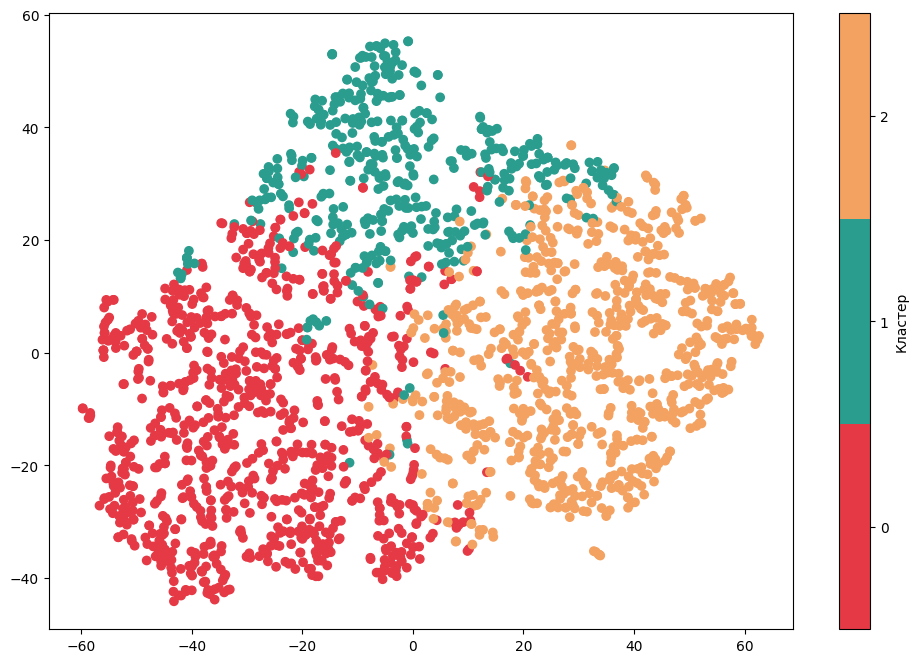

In [23]:
%matplotlib inline
import matplotlib.colors as mcolors

tsne = TSNE(n_components=2, random_state=0)
tsne_digits = tsne.fit_transform(X)

colors = ['#E63946', '#2A9D8F', '#F4A261']
cmap = mcolors.ListedColormap(colors)

plt.figure(figsize=(12, 8))
sc = plt.scatter(tsne_digits[:, 0], tsne_digits[:, 1], c=labels, cmap=cmap)
plt.colorbar(sc, ticks=[0, 1, 2], label='Кластер')
plt.clim(-0.5, 2.5)

In [29]:
len(tsne_digits[:,0])

2239

In [35]:
X['cluster'] = labels
X['tsne_1'] = tsne_digits[:,0]
X['tsne_2'] = tsne_digits[:,1]

X.groupby('cluster')[['Income','Recency','NumStorePurchases',
                        'NumDealsPurchases','days_lifetime',
                        'NumWebVisitsMonth']].mean().round(2)

,Income,Recency,NumStorePurchases,NumDealsPurchases,days_lifetime,NumWebVisitsMonth
cluster,,,,,,
0,-0.83,-0.02,-0.80,-0.27,-0.20,0.49
1,0.02,0.03,0.28,1.39,0.77,0.64
2,0.96,0.01,0.78,-0.46,-0.19,-0.93


Кластер 0 — дохід нижче середнього (−0.83), офлайн-покупок мало (−0.80), але заходить на сайт частіше за середнє (+0.49). Тобто це клієнт з обмеженим бюджетом, часто відвідує сайт але рідко купує в магазині.

Кластер 1 — виділяється одним показником — NumDealsPurchases (+1.39, майже півтора стандартних відхилення). Також довго з компанією (+0.77 days_lifetime) і активний онлайн (+0.64). Дохід середній. Це давній клієнт, який цікавиться акціями і купує переважно по знижках. Лояльний, але маржинальність низька.

Кластер 2 — найвищий дохід (+0.96), найбільше офлайн-покупок (+0.78), майже не ходить на сайт (−0.93). Акції не цікавлять (−0.46). Імовірно це заможні клієнти, які приходить у магазин і купують без знижок. Найцінніший сегмент з точки зору маржі.

Якщо оцінювати візуально то в t-nse кластери розмежовані досить чітко, але зелений налазить на червоний і оранжевий, в PCA також була подібна проблема але це менш помітно і менше кидається в очі ніж в 2D.

Обидва методи виділили чітко преміум-сегмент котрі мають високий дохід і купують офлайн, а також людей з помірною дохідність, лояльний, котрі активно купують по знижкам. Дещо відрізняється результат по третьому сегменту, адже PCA бере за основу Recency, а в t-SNE  навпаки ця фіча не виділяється по жодному сегменту. Однак обидва методи по своєму виділили сегмент з низьким доходом і низькою к-тю покупок як офлайн так і онлайн.